## Analysis systematic results

#### Oxigen

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dataO18 = np.load("data/systematic_analysis/scan_embedding_O18.npz", allow_pickle=True)
dataO20 = np.load("data/systematic_analysis/scan_embedding_O20.npz", allow_pickle=True)
dataO22 = np.load("data/systematic_analysis/scan_embedding_O22.npz", allow_pickle=True)

['gammas', 'ratios', 'inf_gadget', 'inf_emb', 'dE_emb', 'chains']
[  1.           1.37072561   1.87888869   2.57544084   3.5302227
   4.83896665   6.6328955    9.09187971  12.46247232  17.08262993
  23.41559827  32.09636014  43.99530272  60.305488    82.6622766
 113.30729922 155.31321644 212.89180278 291.81624545 400.        ] {0: 1, 1: 1, 2: 2, 3: 1, 4: 2, 5: 1}
[[0.99940767 0.99931127 0.99920946 0.99910676 0.99900819 0.99891832
  0.99884045 0.99877608 0.99872503 0.99868588 0.99865665 0.99863528
  0.99861987 0.99860888 0.99860111 0.99859564 0.9985918  0.99858911
  0.99858724 0.99858593]
 [0.97198857 0.969539   0.96725491 0.96515372 0.96328892 0.96170358
  0.96041214 0.95939952 0.95863033 0.95806035 0.95764577 0.95734826
  0.95713681 0.95698752 0.95688262 0.95680915 0.9567578  0.95672198
  0.95669702 0.95667963]
 [0.83365041 0.82213372 0.8127903  0.80513883 0.79896216 0.79409686
  0.79036587 0.78757416 0.78552716 0.78404938 0.78299461 0.78224783
  0.78172208 0.78135338 0.78109552 0.780

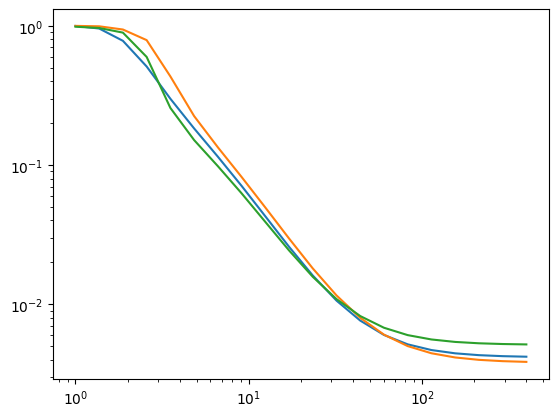

In [ ]:
encoding_style = "inf_gadget"

print(dataO18.files)
print(dataO18["gammas"], dataO18["chains"])
print(dataO18[encoding_style])

plt.plot(dataO18["gammas"], dataO18[encoding_style][:, -1], label="O18")
plt.plot(dataO20["gammas"], dataO20[encoding_style][:, -1], label="O20")
plt.plot(dataO22["gammas"], dataO22[encoding_style][:, -1], label="O22")
plt.legend(fontsize=12)
plt.loglog()
plt.show()

#### Infidelity map: $\gamma$ vs ratio $=J_F/\gamma$


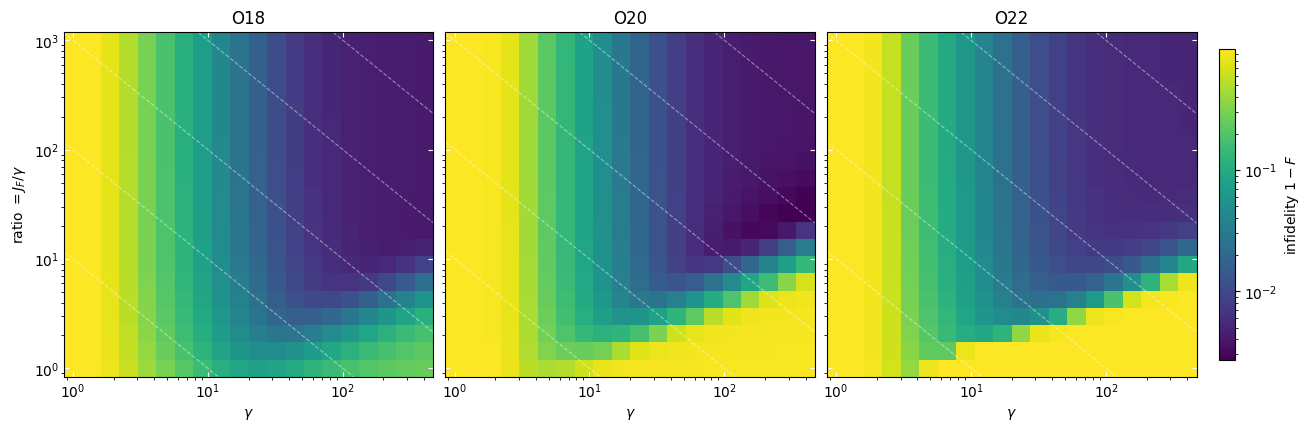

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

datasets = [("O18", dataO18), ("O20", dataO20), ("O22", dataO22)]


def _log_edges(x):
    """Cell edges in log space for a log-spaced coordinate array."""
    lx = np.log10(x)
    mid = 0.5 * (lx[1:] + lx[:-1])
    return 10 ** np.concatenate(([2 * lx[0] - mid[0]], mid, [2 * lx[-1] - mid[-1]]))


# common color scale across the three isotopes
vmin = min(np.nanmin(d["inf_emb"]) for _, d in datasets)
vmax = max(np.nanmax(d["inf_emb"]) for _, d in datasets)
norm = LogNorm(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(
    1, 3, figsize=(13, 4.2), sharex=True, sharey=True, constrained_layout=True
)

for ax, (label, data) in zip(axes, datasets):
    gammas, ratios, inf = data["gammas"], data["ratios"], data["inf_emb"]
    ge, re = _log_edges(gammas), _log_edges(ratios)
    mesh = ax.pcolormesh(ge, re, inf.T, norm=norm, cmap="viridis", shading="flat")

    # dashed iso-J_F lines (J_F = gamma * ratio)
    for jf in [1e1, 1e2, 1e3, 1e4, 1e5]:
        ax.plot(ge, jf / ge, ls="--", lw=0.8, color="w", alpha=0.45)

    ax.set(xscale="log", yscale="log", xlim=(ge[0], ge[-1]), ylim=(re[0], re[-1]))
    ax.set_xlabel(r"$\gamma$")
    ax.set_title(label)
    ax.tick_params(direction="in", top=True, right=True, color="w")

axes[0].set_ylabel(r"ratio $= J_F/\gamma$")
cb = fig.colorbar(mesh, ax=axes, shrink=0.9, pad=0.02)
cb.set_label(r"infidelity $1-F$")
plt.show()